# <span style="color:#2E86C1;">Air Quality Data Analysis</span>

## <span style="color:#28B463;">Overview</span>

This project focuses on analyzing an air quality dataset to understand pollution levels and the environmental factors that influence them.

## <span style="color:#F1C40F;">Objectives</span>

- Explore and understand the dataset  
- Clean missing and inconsistent data  
- Analyze relationships between variables  
- Visualize key patterns in the data  
- Draw meaningful conclusions  

## <span style="color:#E67E22;">Dataset</span>

The dataset contains environmental measurements related to air quality, including:

- Temperature and Humidity  
- Carbon Monoxide (CO) and Nitrogen Dioxide (NO2)  
- Fine Particulate Matter (PM2.5)  
- Wind Speed  
- Air Quality Index (AQI)  

## <span style="color:#8E44AD;">Tools</span>

- Pandas  
- NumPy  
- Matplotlib  

## <span style="color:#E74C3C;">Methodology</span>

- Data Understanding  
- Data Cleaning  
- Data Analysis  
- Data Visualization  
- Conclusion  

## Data Understanding
In this section, we explore the dataset structure, data types, and basic statistics to understand its overall characteristics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/air_quality.csv')
df.head()

,temperature,humidity,CO,NO2,PM2_5,wind_speed,day_type,sensor_reading,AQI,comment
0,6.544193496011898,46.519576,1.395611,70.544606,34.889294,0.226699,Weekend,144.121556,172.0,NaN
1,NaN,87.522970,NaN,NaN,32.603262,6.493965,Weekend,113.646761,98.0,NaN
2,39.297641786717676,62.420427,NaN,84.666497,23.662468,4.777885,Weekday,140.972002,89.0,NaN
3,14.32060827309467,60.721562,1.417170,49.177446,22.972534,9.064197,Weekend,1.223592,67.0,NaN
4,23.2050058308062,54.727658,1.931338,48.870969,27.230089,6.770873,Weekday,163.923843,72.0,bad


In [3]:
print("="*60 + "\n")
print("DATASET SHAPE")
print(df.shape)

print("\n" + "="*60 + "\n")
print("COLUMNS")
print(df.columns)

print("\n" + "="*60 + "\n")
print("DATA TYPES")
print(df.dtypes)

print("\n" + "="*60 + "\n")
print("DATASET INFO")
df.info()

print("\n" + "="*60 + "\n")
print("STATISTICAL SUMMARY")
print(df.describe())

print("\n" + "="*60 + "\n")
print("MISSING VALUES")
print(df.isnull().sum())
print("\n" + "="*60 + "\n")



DATASET SHAPE
(536, 10)


COLUMNS
Index(['temperature', 'humidity', 'CO', 'NO2', 'PM2_5', 'wind_speed',
       'day_type', 'sensor_reading', 'AQI', 'comment'],
      dtype='str')


DATA TYPES
temperature           str
humidity          float64
CO                float64
NO2               float64
PM2_5             float64
wind_speed        float64
day_type              str
sensor_reading    float64
AQI               float64
comment               str
dtype: object


DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 536 entries, 0 to 535
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   temperature     529 non-null    str    
 1   humidity        482 non-null    float64
 2   CO              488 non-null    float64
 3   NO2             500 non-null    float64
 4   PM2_5           500 non-null    float64
 5   wind_speed      534 non-null    float64
 6   day_type        507 non-null    str    
 7   sensor_reading

## Data Cleaning

In this section, the dataset was cleaned according to the data preprocessing concepts covered in the course.

The cleaning process focused on improving data quality by checking for:
- **Incompleteness**: missing values
- **Inconsistency**: duplicated records or different representations of the same concept
- **Noisy data**: random errors or corrupt/meaningless values
- **Outliers**: unusual values detected visually using boxplots

The process was performed systematically for each column. We first explored the data, checked missing and non-missing values, detected corrupt noisy values when applicable, visualized the distribution using boxplots, and then selected an appropriate imputation method.

Cleaning decisions were based on:
- Column data type
- Amount of missing data
- Presence of outliers
- Distribution shape
- Meaning of the variable

This approach ensures that the preprocessing steps are consistent with the course terminology and prepare the dataset for further analysis.


In [4]:
print("="*60)
print("DUPLICATE RECORDS")
print("="*60)

print("Number of duplicate records before:", df.duplicated().sum())

# Duplicate records are a form of inconsistency, so they are removed.
df = df.drop_duplicates()

print("Number of duplicate records after:", df.duplicated().sum())


DUPLICATE RECORDS
Number of duplicate records before: 19
Number of duplicate records after: 0


### Handling Missing Values – Temperature

The temperature column was initially stored as a string type, which indicates the presence of non-numeric or inconsistent values.

First, missing values were checked to understand the extent of the issue.

The column was then converted to numeric format using coercion to handle invalid entries, which resulted in additional missing values.

A statistical summary and boxplot visualization were used to understand the data distribution and detect potential outliers.

Finally, missing values were handled using the median to ensure robustness against extreme values.

Missing values: 7
Non-missing values: 510

After conversion:
Missing values: 34

Summary statistics:
count    483.000000
mean      20.381735
std       10.006408
min       -8.271043
25%       13.911329
50%       20.483724
75%       27.314413
max       52.802295
Name: temperature, dtype: float64


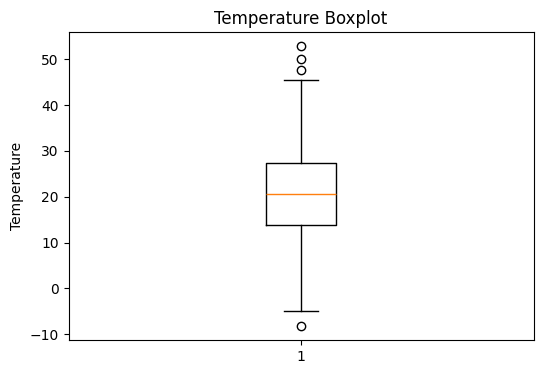


After filling missing values
Missing values: 0


In [18]:
# Check missing values before cleaning
print("Missing values:", df['temperature'].isnull().sum())
print("Non-missing values:", df['temperature'].notnull().sum())
# Convert to numeric (handle invalid values)
df['temperature'] = df['temperature' ].astype(str).str.strip()
df['temperature'] = pd. to_numeric(df['temperature'], errors='coerce')
# Check again after conversion
print("\nAfter conversion:")
print("Missing values:", df['temperature'].isnull().sum())
# Statistical summary
print("\nSummary statistics:")
print(df['temperature'].describe())
# Visualize distribution (boxplot)
plt.figure(figsize=(6,4))
plt.boxplot(df['temperature' ].dropna())
plt.title("Temperature Boxplot")
plt.ylabel("Temperature")
plt. show()
# Fill missing values using median
df['temperature'] = df['temperature'].fillna(df['temperature' ].median())
# Final check
print("\nAfter filling missing values")
print("Missing values:", df['temperature'].isnull().sum())

### Handling Missing Values – Humidity

Missing values were identified and the data distribution was examined using a boxplot.

Since no significant outliers were detected, the mean was used to fill missing values as it represents the average value of the data.

A final check was performed to confirm that all missing values were handled successfully.

Missing values: 53


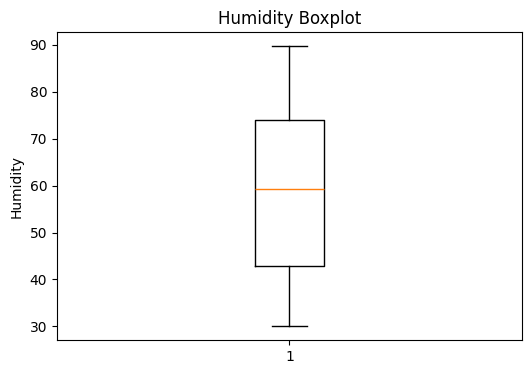

Missing after: 0


In [19]:
print("Missing values:", df['humidity'].isnull().sum())
plt.figure(figsize=(6,4))
plt.boxplot(df['humidity' ].dropna())
plt.title("Humidity Boxplot")
plt.ylabel("Humidity")
plt.show()
df['humidity'] = df['humidity'].fillna(df['humidity'].mean())
print("Missing after:", df['humidity'].isnull().sum())

### Handling Missing Values – CO

Missing values were identified and the data distribution was examined using a boxplot.

The distribution showed no extreme anomalies, but since environmental data may contain fluctuations, the median was used to fill missing values to ensure robustness.

A final check was performed to confirm that all missing values were handled successfully.

Missing values: 45


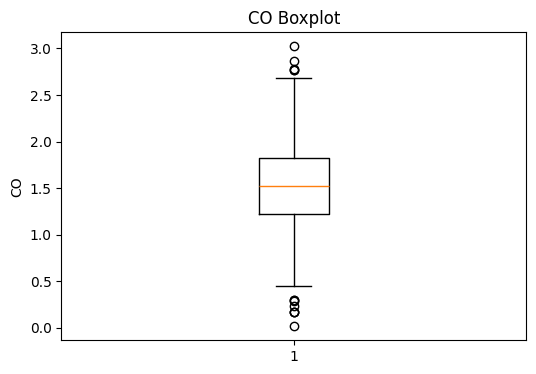

Missing after: 0


In [17]:
print("Missing values:", df['CO'].isnull().sum())

plt.figure(figsize=(6,4))
plt.boxplot(df['CO'].dropna())
plt.title("CO Boxplot")
plt.ylabel("CO")
plt.show()

# Fill missing values
df['CO'] = df['CO'].fillna(df['CO'].median())

print("Missing after:", df['CO'].isnull().sum())

### NO2

The **NO2** column represents Nitrogen Dioxide concentration, which is a numerical air pollution measurement.

Since NO2 concentration cannot be negative, negative values are treated as **corrupt or meaningless noisy data** rather than valid observations.

The column was analyzed to check for:
- Missing values (**incompleteness**)
- Corrupt noisy values (negative values)
- Outliers using a boxplot


In [5]:
# Check missing and non-missing values
print("Missing values:", df['NO2'].isnull().sum())
print("Non-missing values:", df['NO2'].notnull().sum())

# Initial statistical summary
print(df['NO2'].describe())


Missing values: 35
Non-missing values: 482
count    482.000000
mean      41.210564
std       15.639543
min       -0.450202
25%       30.744959
50%       41.959562
75%       50.260410
max       93.388191
Name: NO2, dtype: float64


Negative NO2 values were detected. According to the course terminology, these values are considered **corrupt or meaningless noisy data** because they are clearly invalid for a pollution concentration measurement.

Therefore, they were replaced with `NaN` so they can be handled later using an imputation method.


In [6]:
# Handle corrupt or meaningless noisy data in NO2
# Negative NO2 values are invalid, so they are converted to missing values (NaN).
df.loc[df['NO2'] < 0, 'NO2'] = np.nan


A boxplot was used to visualize the distribution of the data and detect the presence of outliers.

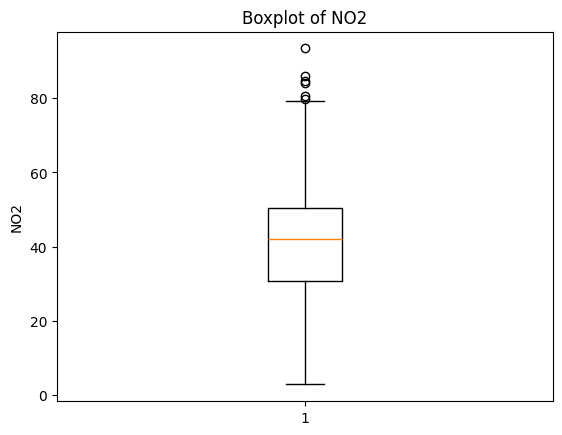

In [7]:
plt.boxplot(df['NO2'].dropna())
plt.title('Boxplot of NO2')
plt.ylabel('NO2')
plt.show()

The NO2 column contains outliers. Since outliers can strongly affect the mean, **median imputation** was used to replace missing values.

This follows the course rule: use the **median** for skewed numerical data or numerical data affected by outliers.


In [8]:
# Count missing values before imputation
before = df['NO2'].isnull().sum()
print("Missing before imputation:", before)

# Median imputation for numerical data affected by outliers
df['NO2'] = df['NO2'].fillna(df['NO2'].median())

# Count missing values after imputation
after = df['NO2'].isnull().sum()
print("Missing after imputation:", after)


Missing before imputation: 37
Missing after imputation: 0


### NO2 Conclusion

The **NO2** column was cleaned and prepared for analysis.

Negative values were identified as **corrupt or meaningless noisy data** and were converted to missing values (`NaN`). A boxplot showed the presence of outliers, so **median imputation** was used to fill missing values because the median is more robust to extreme values.

Overall, the NO2 column was handled using appropriate data cleaning and imputation steps.


### PM2.5

The **PM2.5** column represents fine particulate matter concentration, which is a numerical air pollution measurement.

Since PM2.5 concentration cannot be negative, negative values are treated as **corrupt or meaningless noisy data** rather than valid observations.

The column was analyzed to check for:
- Missing values (**incompleteness**)
- Corrupt noisy values (negative values)
- Outliers using a boxplot


In [9]:
# Check missing and non-missing values
print("Missing values:", df['PM2_5'].isnull().sum())
print("Non-missing values:", df['PM2_5'].notnull().sum())

# Initial statistical summary
print(df['PM2_5'].describe())


Missing values: 36
Non-missing values: 481
count    481.000000
mean      25.247664
std       10.055082
min       -0.401357
25%       18.285716
50%       25.593458
75%       32.035017
max       53.147603
Name: PM2_5, dtype: float64


Negative PM2.5 values were detected. According to the course terminology, these values are considered **corrupt or meaningless noisy data** because they are invalid for a pollution concentration measurement.

Therefore, they were replaced with `NaN` so they can be handled later using an imputation method.


In [10]:
# Handle corrupt or meaningless noisy data in PM2.5
# Negative PM2.5 values are invalid, so they are converted to missing values (NaN).
df.loc[df['PM2_5'] < 0, 'PM2_5'] = np.nan


A boxplot was used to visualize the distribution of the data and detect the presence of outliers.

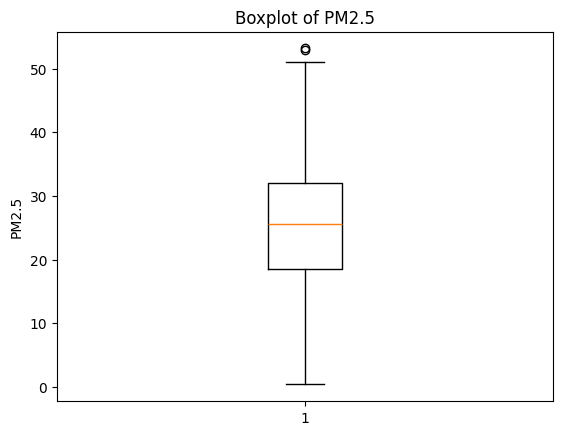

In [11]:
plt.boxplot(df['PM2_5'].dropna())
plt.title('Boxplot of PM2.5')
plt.ylabel('PM2.5')
plt.show()

The PM2.5 column contains outliers. Since outliers can strongly affect the mean, **median imputation** was used to replace missing values.

This follows the course rule: use the **median** for skewed numerical data or numerical data affected by outliers.


In [12]:
# Count missing values before imputation
before = df['PM2_5'].isnull().sum()
print("Missing before imputation:", before)

# Median imputation for numerical data affected by outliers
df['PM2_5'] = df['PM2_5'].fillna(df['PM2_5'].median())

# Count missing values after imputation
after = df['PM2_5'].isnull().sum()
print("Missing after imputation:", after)


Missing before imputation: 38
Missing after imputation: 0


### PM2.5 Conclusion

The **PM2.5** column was cleaned and prepared for analysis.

Negative values were identified as **corrupt or meaningless noisy data** and were converted to missing values (`NaN`). A boxplot showed the presence of outliers, so **median imputation** was used to fill missing values because the median is more robust to extreme values.

Overall, the PM2.5 column was handled using appropriate data cleaning and imputation steps.


### Wind Speed

The **wind_speed** column represents wind speed measurements and is a numerical variable.

Since wind speed cannot be negative, negative values are treated as **corrupt or meaningless noisy data** rather than valid observations.

The column was analyzed to check for:
- Missing values (**incompleteness**)
- Corrupt noisy values (negative values)
- Outliers using a boxplot


In [13]:
# Check missing and non-missing values
print("Missing values:", df['wind_speed'].isnull().sum())
print("Non-missing values:", df['wind_speed'].notnull().sum())

# Initial statistical summary
print(df['wind_speed'].describe())


Missing values: 2
Non-missing values: 515
count    515.000000
mean       5.166078
std        2.926577
min        0.007080
25%        2.677256
50%        5.286698
75%        7.681307
max        9.982826
Name: wind_speed, dtype: float64


The wind_speed column was checked for negative values. Since wind speed cannot be negative, such values are considered **corrupt or meaningless noisy data** and are replaced with `NaN` if present.


In [14]:
# Handle corrupt or meaningless noisy data in wind_speed
# Negative wind speed values are invalid, so they are converted to missing values (NaN).
df.loc[df['wind_speed'] < 0, 'wind_speed'] = np.nan


A boxplot was used to visualize the distribution of the data and detect the presence of outliers.

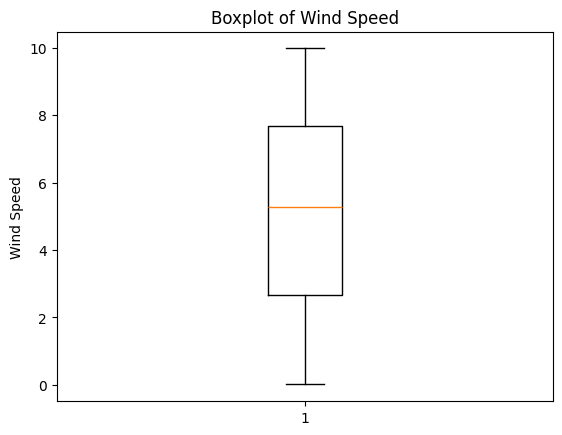

In [15]:
plt.boxplot(df['wind_speed'].dropna())
plt.title('Boxplot of Wind Speed')
plt.ylabel('Wind Speed')
plt.show()

The wind_speed column does not show significant outliers and appears relatively symmetric. Therefore, **mean imputation** was used to replace missing values.

This follows the course rule: use the **mean** for numerical symmetric data when outliers are not a major issue.


In [16]:
# Count missing values before imputation
before = df['wind_speed'].isnull().sum()
print("Missing before imputation:", before)

# Mean imputation for numerical data without significant outliers
df['wind_speed'] = df['wind_speed'].fillna(df['wind_speed'].mean())

# Count missing values after imputation
after = df['wind_speed'].isnull().sum()
print("Missing after imputation:", after)


Missing before imputation: 2
Missing after imputation: 0


### Wind Speed Conclusion

The **wind_speed** variable contains missing values but no invalid or noisy values were detected.

No negative wind_speed values were found. A boxplot showed no significant outliers, indicating that the data is relatively well-behaved. Therefore, missing values were handled using mean imputation, as the distribution appears relatively symmetric.